In [1]:
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

###model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline

### evaluation metrics
from sklearn.metrics import confusion_matrix,classification_report

DATA LOADING 

In [2]:
df=pd.read_csv(r"C:\Users\USER\Desktop\MY DATASETS\student_dropout_dataset_v3.csv")

In [3]:
df.head(8)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,NaN,0
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0
7,8,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0


In [4]:
df.info() # this is to confirm if our columns are set to the right data type because if they are not, we may encounter error performing some functions 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [5]:
df.isna().sum() # this is to see if we have any missing value in our dataset and with the sum() function, we get the total missing values per column

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [6]:
num_col=df.select_dtypes(include='number') #this selects only the numeric columns in our dataset.
num_col.describe().T #this gives a summary statistics to our numerical comlumns 

,count,mean,std,min,25%,50%,75%,max
Student_ID,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.50,7500.25,10000.00
Age,10000.0,21.026060,2.139810,17.0,19.50,21.00,22.50,29.60
Family_Income,9500.0,38377.247474,20496.232179,25000.0,25000.00,29740.50,44520.00,316601.00
Study_Hours_per_Day,9500.0,4.014592,1.295450,0.5,3.16,4.00,4.87,8.98
Attendance_Rate,10000.0,81.736830,8.220930,38.2,76.40,81.80,87.30,100.00
Assignment_Delay_Days,10000.0,1.799700,1.344307,0.0,1.00,2.00,3.00,8.00
Travel_Time_Minutes,10000.0,30.179260,11.918870,5.0,21.90,30.20,38.40,74.90
Stress_Index,9500.0,5.507147,1.765951,1.0,4.30,5.50,6.70,10.00
GPA,10000.0,2.308440,1.061717,0.0,1.55,2.35,3.12,4.00
Semester_GPA,10000.0,2.300057,1.074407,0.0,1.52,2.35,3.15,4.00


                                                            HANDLING MISSNG VALUES
1) The missing values will be filled column by column based on the summary statistics above. Family_Income column is rightly skewed and 
we have outliers(few families with high income), who increased our mean value.Therefore, this column will be filled with median value.
    
2) Study_Hours_per_Day and Stress_Index columns will be filled with mean value. These columns are not skewed and the mean and median are of no difference. The mean will be suitable for these columns.

3) The last column with missing values is a categorical column and it can be filled with neither mean nor median.Therefore, this column will be filled with the mode, the most frequent value in the colume.

In [7]:
df['Family_Income']=df['Family_Income'].fillna(df['Family_Income'].median()) #this fills the family_income column  with median

In [8]:
df['Study_Hours_per_Day']=df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean()) # this fills the study_hours_per_day column with the mean value

In [9]:
df['Stress_Index']=df['Stress_Index'].fillna(df['Stress_Index'].mean()) #this fills Stress_Index column with the mean value 

In [10]:
df['Parental_Education']=df['Parental_Education'].fillna(df['Parental_Education'].mode()[0]) # this fills this categorical column with the most frequent value

In [11]:
df.isna().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [12]:
df.head() # to confirm if our fillna operation was successful and effective 

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.360000,86.1,2,20.4,Yes,No,5.500000,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.300000,68.0,2,44.0,No,No,6.800000,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.400000,70.9,0,48.9,Yes,No,5.500000,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.014592,82.2,2,38.6,No,No,5.507147,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.190000,75.7,1,23.0,No,No,7.000000,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [13]:
df['Gender'].value_counts()

Gender
Female    5011
Male      4989
Name: count, dtype: int64

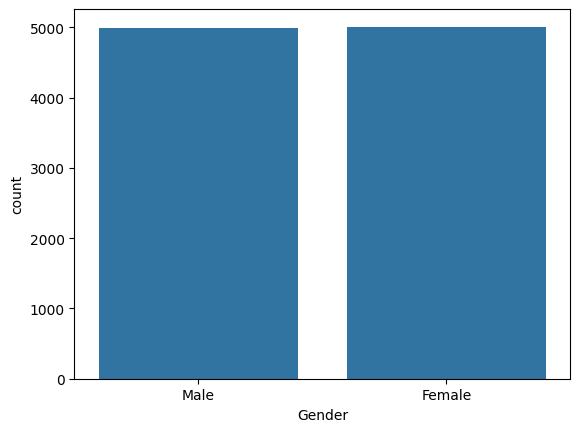

In [14]:
sns.countplot(data=df,x='Gender')  # this shows the number of students by gender
plt.show()

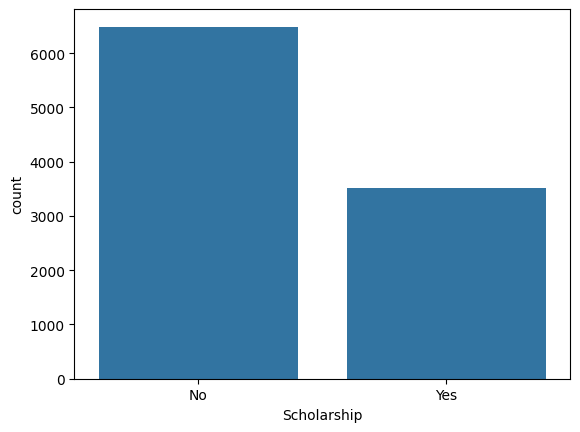

In [15]:
sns.countplot(data=df,x='Scholarship')  
plt.show()

In [16]:
## this cell of code helps us to know the proporton of male and female who are working and are not working(pert_time_job).This shows that both
# male and female are active. Although we have more working male and less non working male compared to female and given that female population 
# is more than male ,the gap is not wide. The pendulum can easily bend to any side 


non_working_female=len(df[(df['Gender']=='Female') & (df['Part_Time_Job']=='No')])
working_female=len(df[(df['Gender']=='Female') & (df['Part_Time_Job']=='Yes')])    
working_male=len(df[(df['Gender']=='Male') & (df['Part_Time_Job']=='Yes')])
non_working_male=len(df[(df['Gender']=='Male') & (df['Part_Time_Job']=='No')])

print(f'WORKING_FEMALE: {working_female}')
print(f'NON_WORKING_FEMALE:{non_working_female}')
print(f'WORKING_MALE:{working_male}')
print(f'NON_WORKING_MALE:{non_working_male}')

WORKING_FEMALE: 1983
NON_WORKING_FEMALE:3028
WORKING_MALE:2021
NON_WORKING_MALE:2968


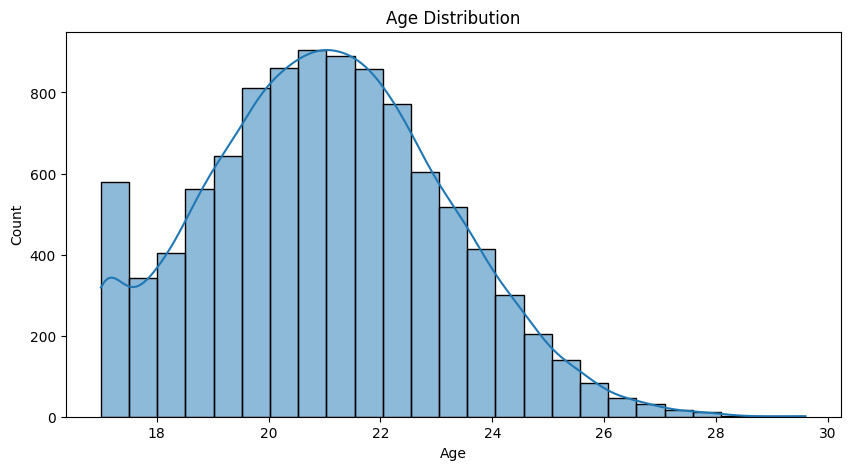

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='Age',kde=True,bins=25)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

The Age distribution of male and female are the same. Both gender have similar age group distribution and there is no much difference between them. This is depicted by the next diagram 

<Figure size 1000x500 with 0 Axes>

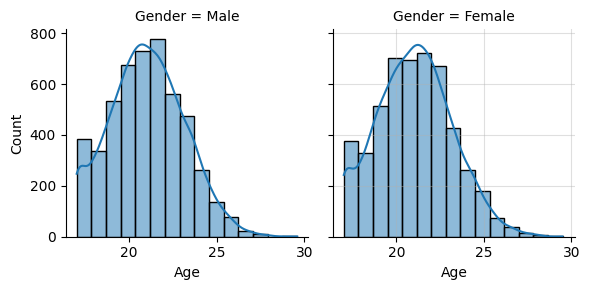

In [18]:
plt.figure(figsize=(10,5))
FG=sns.FacetGrid(df,col='Gender')
FG.map_dataframe(sns.histplot,x='Age',kde=True,bins=15)
plt.grid(True,alpha=0.4)

Irrespective of whether the students have a part time job or not or they are male of female , most of them have 4 hours to study per day. This is in line with the mean gotten from our summary statistics. This means that gender or side hustle does not not have much effects on the students' study hour. This is shown the graph below.

<Figure size 1000x500 with 0 Axes>

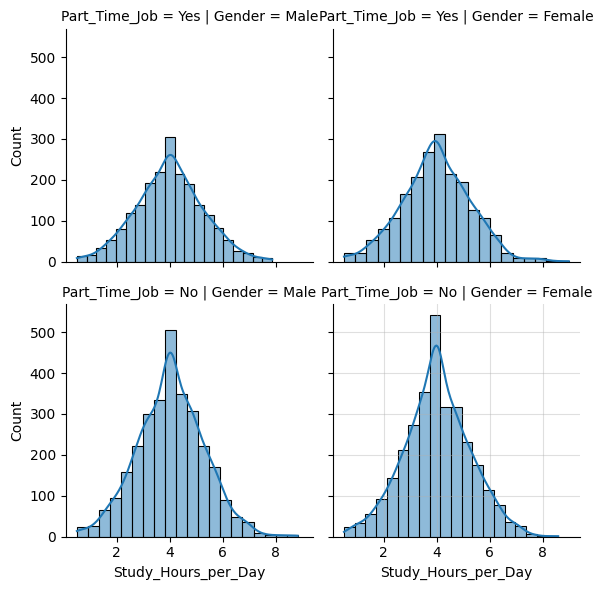

In [19]:
plt.figure(figsize=(10,5))
FG=sns.FacetGrid(df,col='Gender',row='Part_Time_Job')
FG.map_dataframe(sns.histplot,x='Study_Hours_per_Day',kde=True,bins=20)
plt.grid(True,alpha=0.4)

                                RELATIONSHIP BETWEEN DROPOUT AND PART TIME JOB AND GPA

The diagram below showcase that although GPA is the detrminant factor of student drop out, it is not the sole factor that determine dropout. We have some students who has 4.0 GPA and still dropout and some has less than 1 GPA has did not. But most students who has 4.0 GPA did not dropout while most students with  less than 1.3 GPA drop out.

Also,since GPA is the determinant factor, students who do not take on part time jobs have higher chance of having higher GPA compared to those who take on part time jobs(this is seen when the top left plot is compared to the bottom left in the diagram below). On the other hand, this does not directly applies on those who dropped out. Their GPA is comparably the same even when they take up a part time job or not. 

What this means is that GPA is what keep most of the students but it is not exclusively what makes some to dropout

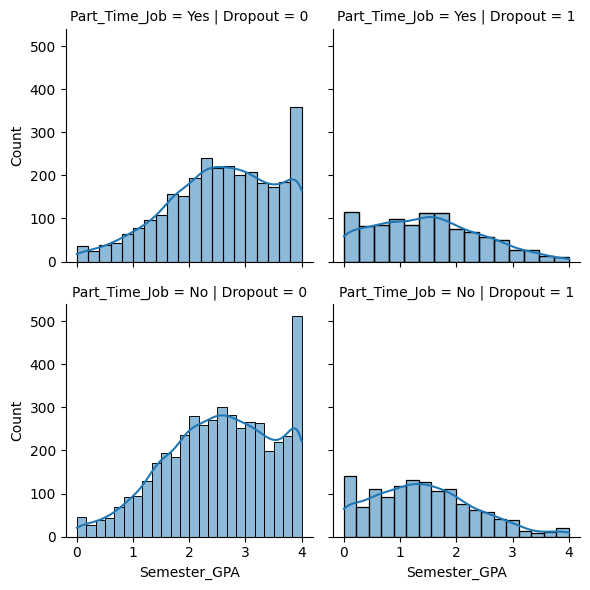

In [20]:
FG=sns.FacetGrid(df,col='Dropout',row='Part_Time_Job')
FG.map_dataframe(sns.histplot,x='Semester_GPA',kde=True)

                                                    FAMILY INCOME DISTRIBUTION
As seen earlier with the summary statistics(25000.00[25%], 29740.50[50%], 44520.00[75%], 316601.00[max]),75% of the students are below 44,520 as income and the max is too far the 75%. This means that only a few of the students are from high income family. Putting in plain number,7,500 out of 10,000  students are from family with less than 44,520 income,while the remaining 2,500 are from above. 

From the histogram below, the remaining 2,500 students with family income greater than 44,520 are distributed within 50,000 income with approximately 900 students, 60,000 around 500 students,70,000 around 400 students,80,000 around 300 students, and 90-100,000 around 200 students while the remaning sudents are distributed across 100,000+ to 300,000+.

This shows a huge imbalance and this is why our data is is rightly skewed. There are a few big values that increases our mean and this distort the reality of our data.

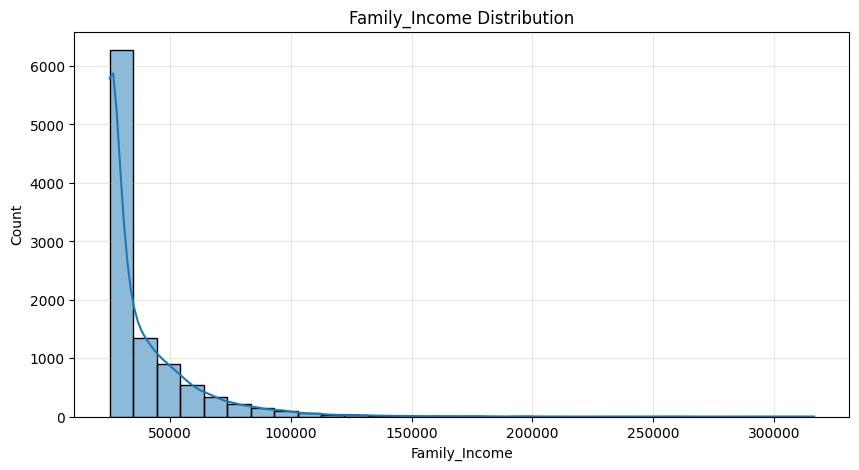

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='Family_Income',bins=30,kde=True)
plt.xlabel('Family_Income')
plt.ylabel('Count')
plt.title('Family_Income Distribution')
plt.grid(True,alpha=0.3)
plt.show()

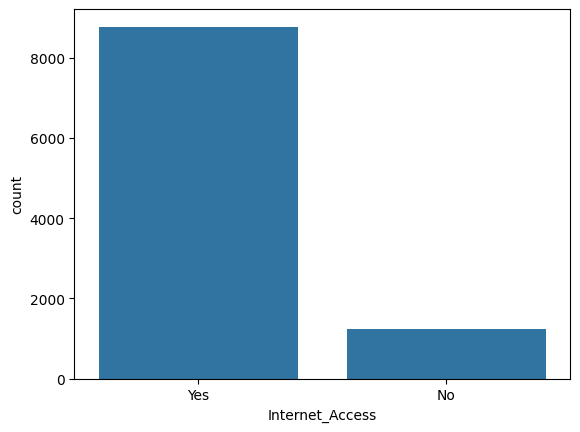

Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

In [22]:
sns.countplot(data=df,x='Internet_Access')      # We have more students having access to internet than those that do not
plt.show()

df['Internet_Access'].value_counts()

                                                            ATTENDANCE RATE
The histogram below shows that there are students with less than 40% in their attendance and this is in line with the Min shown in the summary statistics earlier. However, we have very few students within the range of 38 to 60. But from 60, we have a low and steady increase in the number of students. We have most students with attendance rate around 75 to 88(we have 80 and 82 to have the equal highest number of students),then we have a steady decrease from 90 to 100.

This shows skewness, we have few extreme low values in this set. However, these few low values could not pull our mean out of proportion(we only have a difference of 0.1 between our mean and median). Boxplot could be helpful in identifying outliers.

The boxplot shows that we have outliers from 60 attendance rate downward,that is, from 59 to 38.2. This will handled to have good performance with our model.

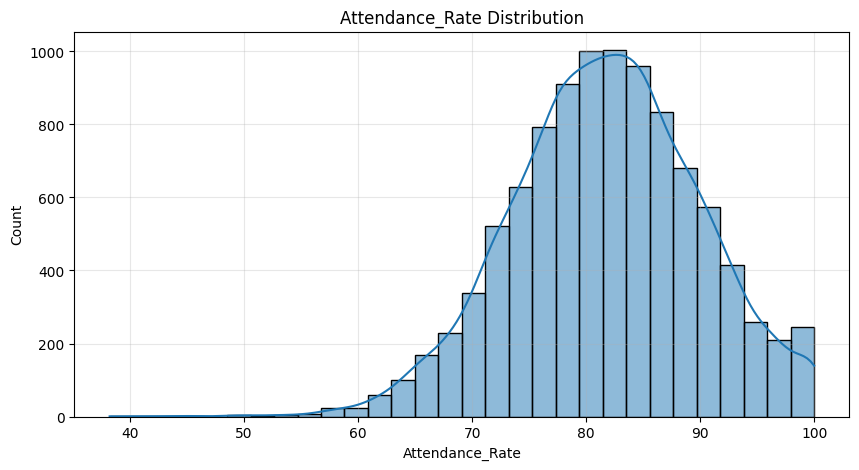

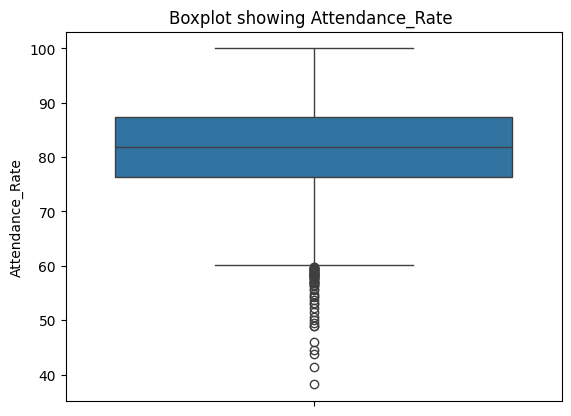

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='Attendance_Rate',bins=30,kde=True)
plt.xlabel('Attendance_Rate')
plt.ylabel('Count')
plt.title('Attendance_Rate Distribution')
plt.grid(True,alpha=0.3)
plt.show()

sns.boxplot(df['Attendance_Rate'])
plt.title('Boxplot showing Attendance_Rate ')
plt.show()

                                                                Assignment_Delay_Days
Students are more likely to submit assignment a day after dealine and this set of students are followed by students who delay their submissin by 2 days. Only about 1,700 students do not delay the submission. We have fewer students in 5 days and above and they are below 500 in each number of days.

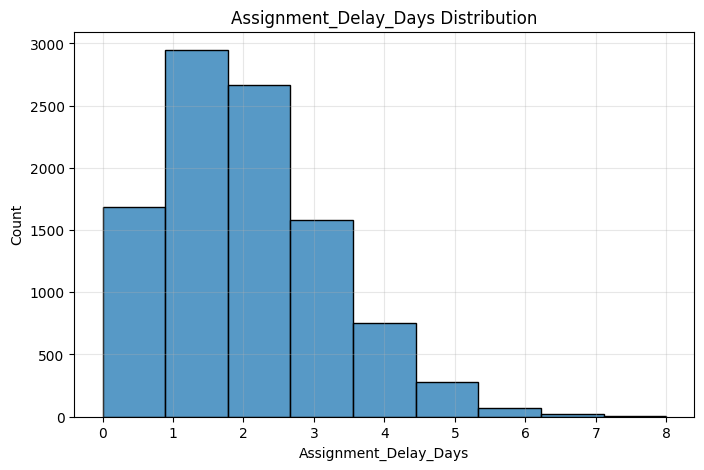

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Assignment_Delay_Days',bins=9)
plt.xlabel('Assignment_Delay_Days')
plt.ylabel('Count')
plt.title('Assignment_Delay_Days Distribution')
plt.grid(True,alpha=0.3)
plt.show()

                                                                Travel_Time_Minutes
This column entails students' daily commute and with the histogram below , most students commute for 20 to 40 minutes daily. This could be from home to school and also to their part time jobs for those that has one. Only around 480 students has less than 10 minutes daily journey. We also have students who commute for more than 40 to 70+ minutes but they are few compared to those who commute for 20 - 40 minutes daily.
A relationship can not be established between Travel time and Part time jobs to decide if it is only school to home distance or work inclusive.

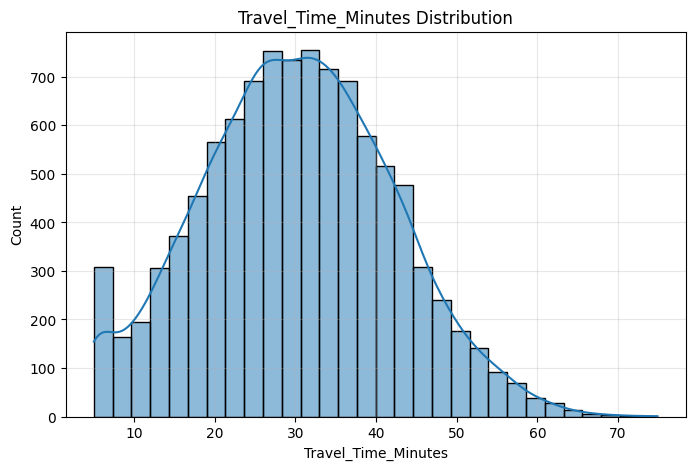

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Travel_Time_Minutes',bins=30,kde=True)
plt.xlabel('Travel_Time_Minutes')
plt.ylabel('Count')
plt.title('Travel_Time_Minutes Distribution')
plt.grid(True,alpha=0.3)
plt.show()

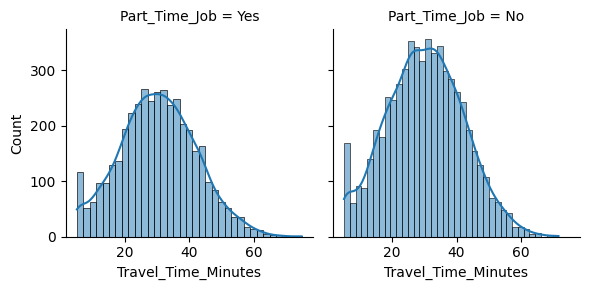

In [26]:
FG=sns.FacetGrid(df,col='Part_Time_Job')
FG.map_dataframe(sns.histplot,x='Travel_Time_Minutes',kde=True)

                                RELATIONSHIP BETWEEN VARIABLES
From the family income, most of the students are from middle family with less than 50,000 monthly income. This means family income can not a determinant  factor:the student that came from the family with highest income dropped out. However, students with low GPA are more likely to drop out.

Students with high stress index have less GPA and high rate of dropouts. It is like a chain reaction.
This combined with the heatmap that follows which shows correlation between variables,study hour and assignment delay days are kind of way correlated to GPA which is the determinant factor of dropout.

Other variables do not show any explicit relationship.

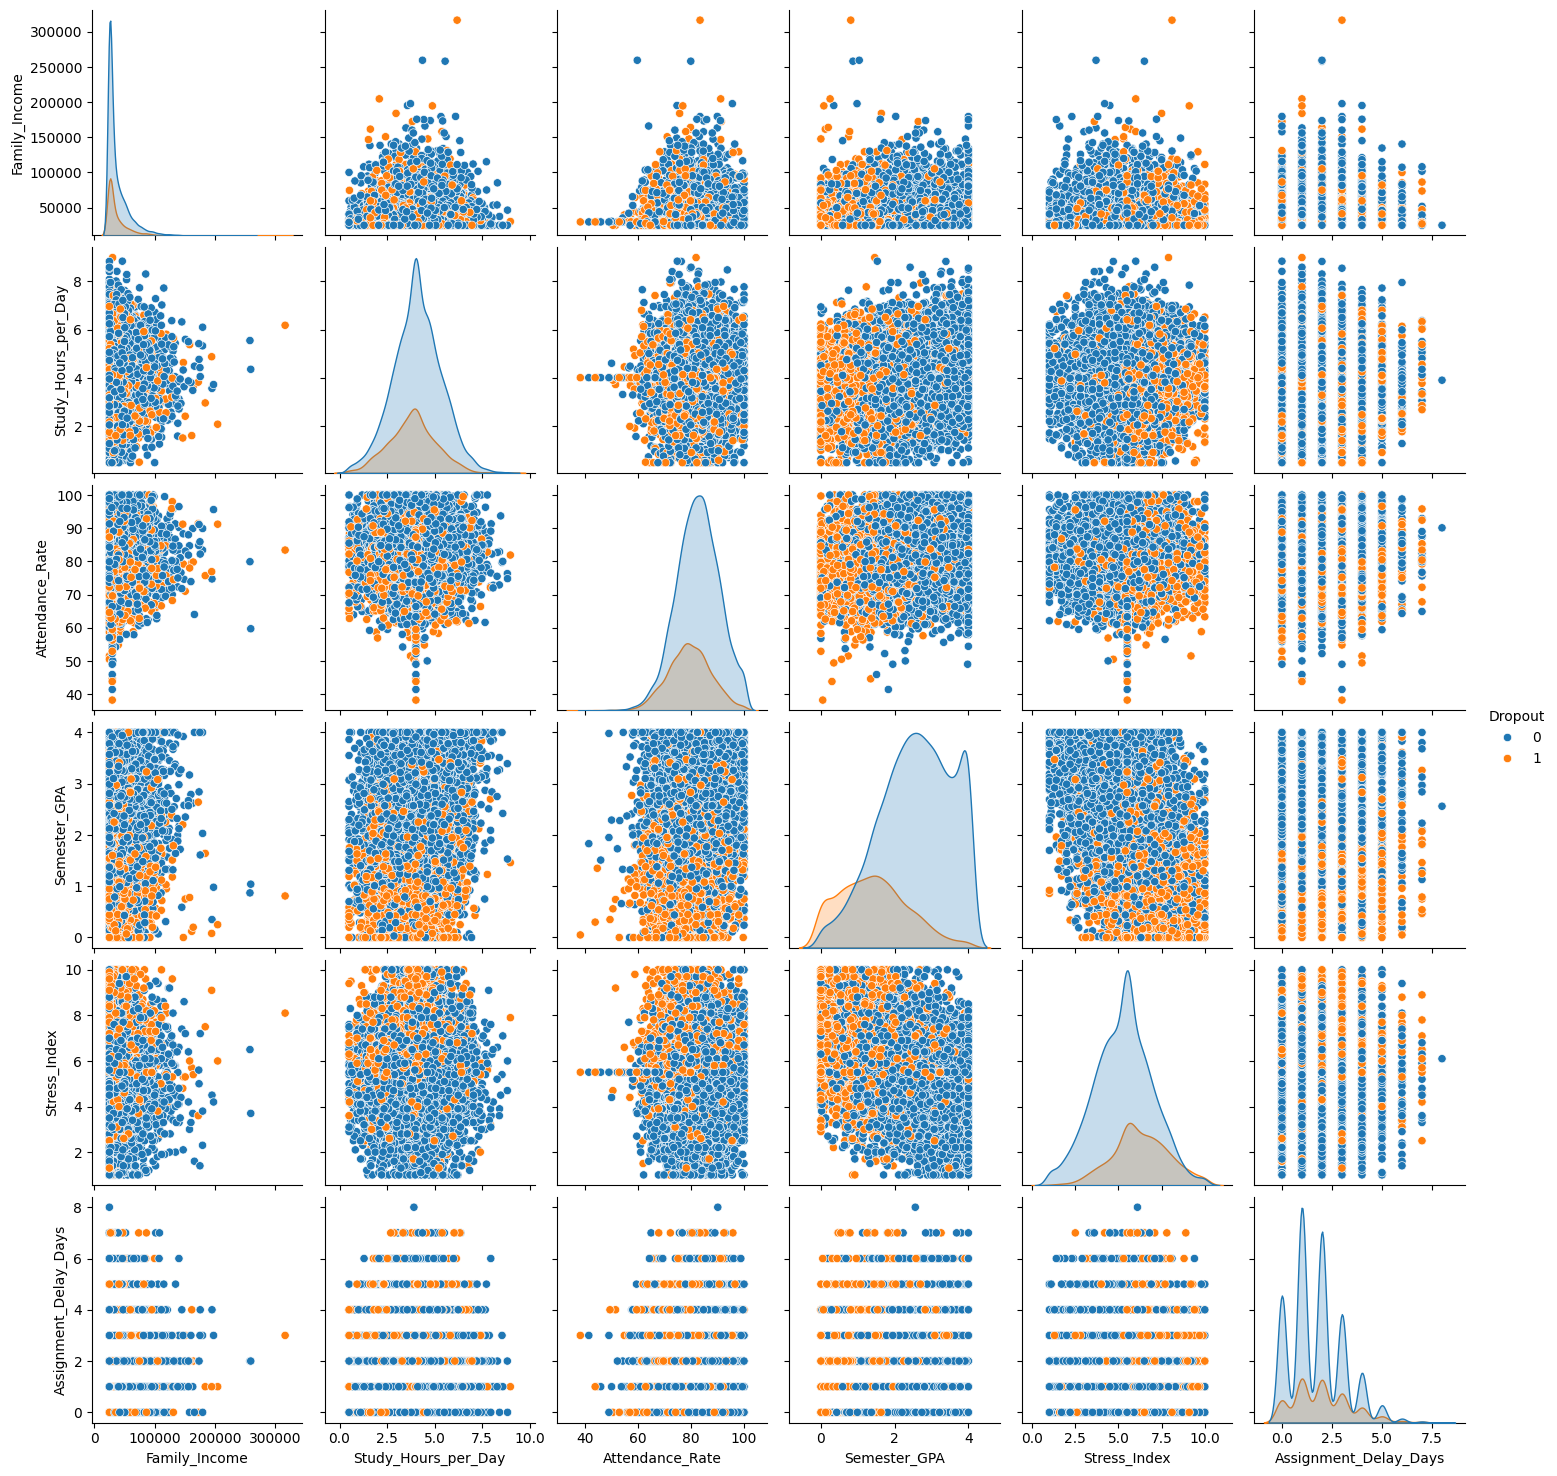

In [27]:
sns.pairplot(df[['Family_Income','Study_Hours_per_Day','Attendance_Rate', 'Semester_GPA','Stress_Index','Assignment_Delay_Days','Dropout']],hue='Dropout',diag_kind='kde')
plt.show()

<Axes: >

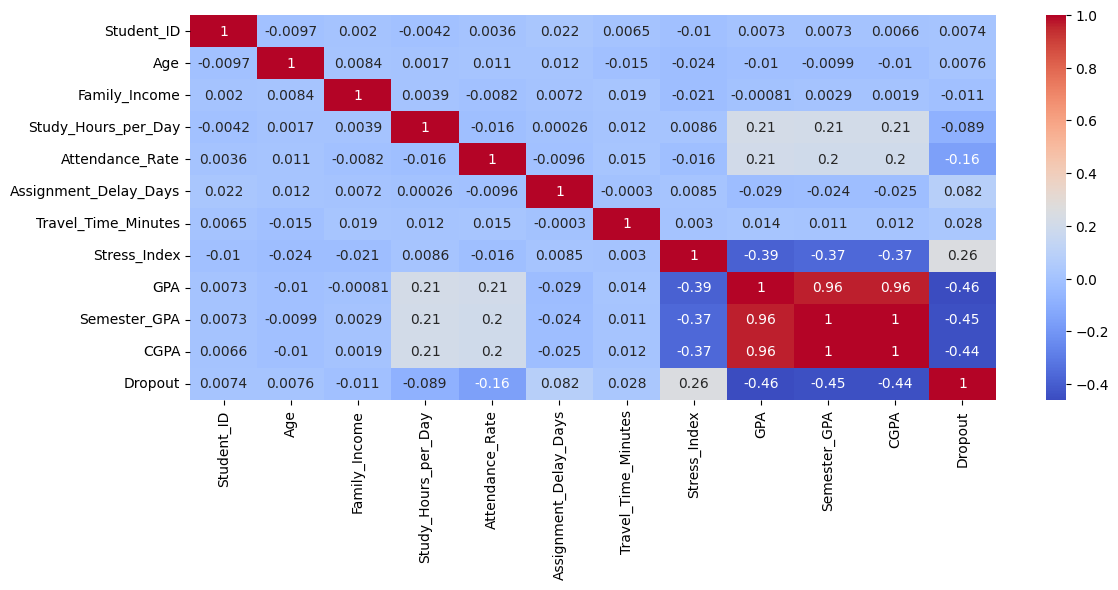

In [28]:
cor=num_col.corr()
plt.figure(figsize=(13,5))
sns.heatmap(cor,annot=True,cmap='coolwarm')

                                                                Stress Index
We do not have a student without stress,including those that dropped out and those who do not. The stress index is clustered around 5 to 7 indexes, this could be as a result of students taking on part time jobs and at the same time the long distance they have to commute daily. Only a few of them commute less than 10mins per day. We have more than 1000 students with roughly 5.8 or 5.9 stress index.

However, with the following plot, there is no much difference between the stress index of those with part time job and those without. The only difference is the number of those who have part time jobs and who who do not.

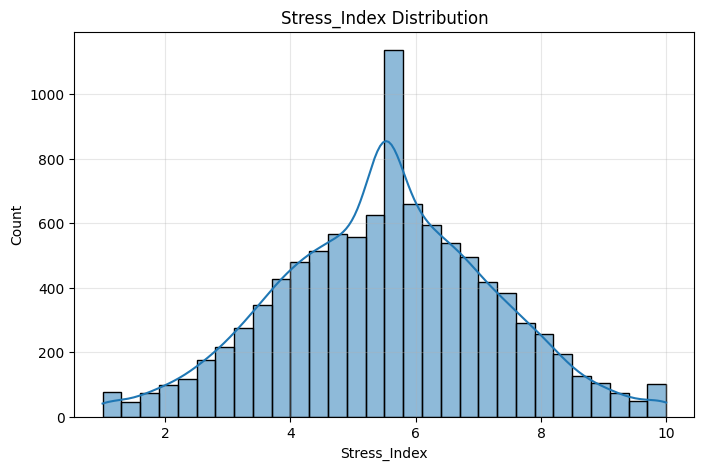

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Stress_Index',bins=30,kde=True)
plt.xlabel('Stress_Index')
plt.ylabel('Count')
plt.title('Stress_Index Distribution')
plt.grid(True,alpha=0.3)
plt.show()

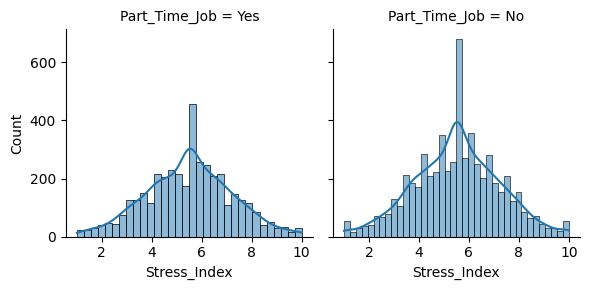

In [30]:
FG=sns.FacetGrid(df,col='Part_Time_Job')
FG.map_dataframe(sns.histplot,x='Stress_Index',kde=True)

                                                GRADE(GPA,CGPA,Semester_GPA)
The performmance is slightly equally distributed.The GPA,CGPA are clustered arounf 1.5 to 3.0 with the single grade with highest number of 4.0. There is a steady but low increase from 1.5 but it started decreasing from 3.0 until it peaked at 4.0. We have more pass than fail but we are likely to have more of average students in the class.

Semester_GPA will be used for analysis and comparison. The three of these are all equal.

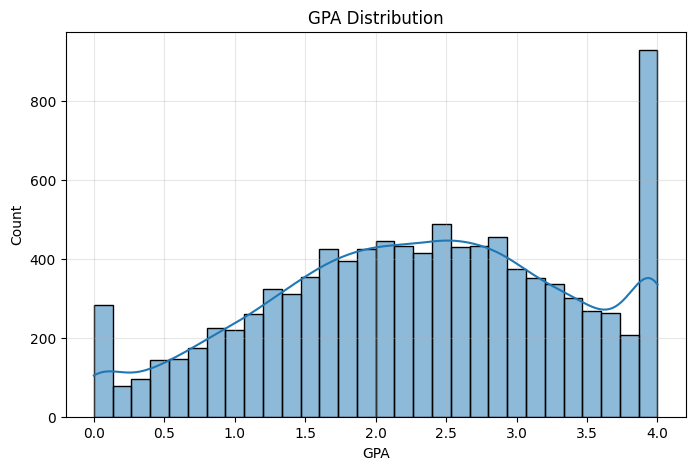

Dropout
0    7646
1    2354
Name: count, dtype: int64

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='GPA',bins=30,kde=True)
plt.xlabel('GPA')
plt.ylabel('Count')
plt.title('GPA Distribution')
plt.grid(True,alpha=0.3)
plt.show()

df['Dropout'].value_counts()

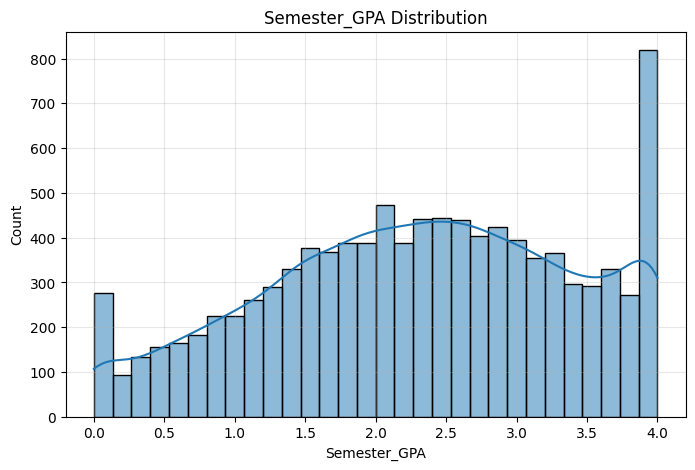

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Semester_GPA',bins=30,kde=True)
plt.xlabel('Semester_GPA')
plt.ylabel('Count')
plt.title('Semester_GPA Distribution')
plt.grid(True,alpha=0.3)
plt.show()

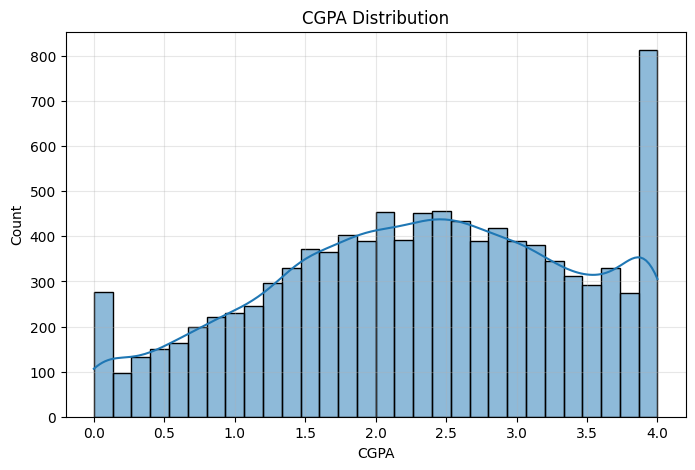

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='CGPA',bins=30,kde=True)
plt.xlabel('CGPA')
plt.ylabel('Count')
plt.title('CGPA Distribution')
plt.grid(True,alpha=0.3)
plt.show()

                                                                    POPULATION

NUMBER OF STUDENTS IN EACH YEAR

In [34]:
df['Semester'].value_counts()

Semester
Year 4    2536
Year 3    2521
Year 2    2488
Year 1    2455
Name: count, dtype: int64

OVER POPULATION BY DEPARTMENT

In [35]:
df['Department'].value_counts()

Department
Science        2061
Arts           2026
Business       2002
CS             1974
Engineering    1937
Name: count, dtype: int64

PARENT STAT.

In [36]:
df['Parental_Education'].value_counts()

Parental_Education
Bachelor       4460
High School    3072
Master         2003
PhD             465
Name: count, dtype: int64

                    NUMBER OF STUDENTS IN EACH DEPARTMENT BY YEAR  
The gap  between departments by year is not so wide but different department dominate each year. Business department dominates Year_1 and CS department has the least population in that year. Year_2 is dominated by Arts department while Business has the least students. Year_3 is also more populated by Arts students with CS being least populated for that year. Finally , Year_4 has more Science students this year with Engineering department with the least population.

The difference is kind od insignificant that the difference between year 1 most populated department and least populated is 25 students,year 2 with 46 difference,year3 with 41 difference and year 4 with 62 difference.

In [37]:
year_1=df[df['Semester']=='Year 1'].groupby('Department')['Student_ID'].count()
Year_1=pd.DataFrame(year_1)
Year_1



,Student_ID
Department,
Arts,487
Business,504
CS,479
Engineering,486
Science,499


In [38]:
year_2=df[df['Semester']=='Year 2'].groupby('Department')['Student_ID'].count()
Year_2=pd.DataFrame(year_2)
Year_2

,Student_ID
Department,
Arts,526
Business,480
CS,487
Engineering,487
Science,508


In [39]:
year_3=df[df['Semester']=='Year 3'].groupby('Department')['Student_ID'].count()
Year_3=pd.DataFrame(year_3)
Year_3

,Student_ID
Department,
Arts,522
Business,518
CS,481
Engineering,486
Science,514


In [40]:
year_4=df[df['Semester']=='Year 4'].groupby('Department')['Student_ID'].count()
Year_4=pd.DataFrame(year_4)
Year_4

,Student_ID
Department,
Arts,491
Business,500
CS,527
Engineering,478
Science,540


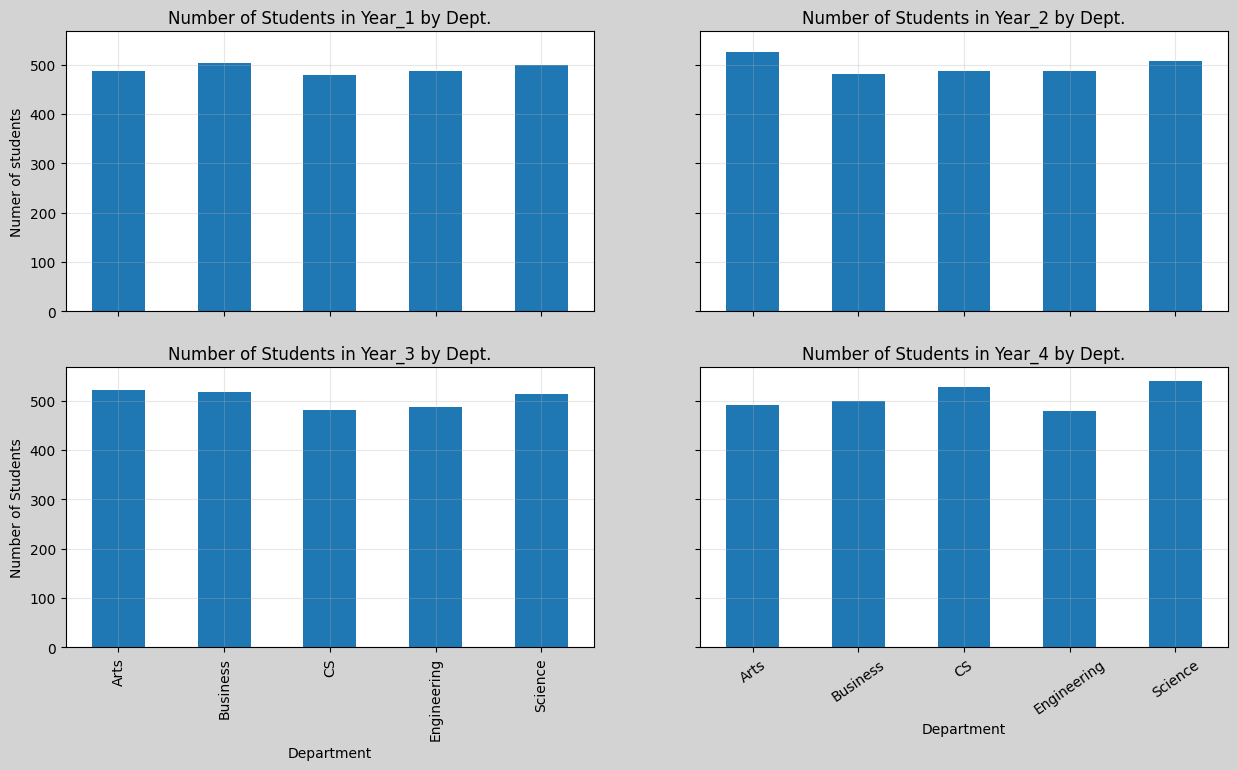

In [41]:
fig,axes=plt.subplots(2,2,figsize=(15,8),sharey=True,sharex=True,facecolor='lightgray')
Year_1.plot(kind='bar',ax=axes[0,0])
axes[0,0].grid(True,alpha=0.3)
axes[0,0].set_title('Number of Students in Year_1 by Dept.')
axes[0,0].legend().set_visible(False)
axes[0,0].set_ylabel('Numer of students')

Year_2.plot(kind='bar',ax=axes[0,1])
axes[0,1].grid(True,alpha=0.3)
axes[0,1].set_title('Number of Students in Year_2 by Dept.')
axes[0,1].legend().set_visible(False)

    
Year_3.plot(kind='bar',ax=axes[1,0])
axes[1,0].grid(True,alpha=0.3)
axes[1,0].set_title('Number of Students in Year_3 by Dept.')
axes[1,0].legend().set_visible(False)
axes[1,0].set_ylabel('Number of Students')

Year_4.plot(kind='bar',ax=axes[1,1])
axes[1,1].grid(True,alpha=0.3)
axes[1,1].set_title('Number of Students in Year_4 by Dept.')
axes[1,1].legend().set_visible(False)

plt.tick_params(rotation=35)


                                NUMBER OF STUDENTS IN EACH YEAR BY DEPARTMENT AND DROPOUT
2,354 students dropout out of 10,000 . That is 23.54% of students. That means 1 out of 4 students dropout (approxiamately)
                                
All departments across different semester have more than 100 dropouts. Year 4 Science department  has the most dropout with 132 students and year 1 science department has the least dropout across all years. Per year, we have more business dropout in year 2 and more Arts dropout in year 3. The dropouts across the year by department do not outrightly outweigh the other year or department. 

Therefore, whatever factor could be responsible for dropout , it is not individual,year or semester peculiar. It is a factor that affect all students irrespective of the year or department. This has been been from the variable distributions explained earliar, our data has not been total skewed except for family_income that is rightly skewed.

In [42]:
df['Dropout'].value_counts()   

Dropout
0    7646
1    2354
Name: count, dtype: int64

In [43]:
year_1=df[df['Semester']=='Year 1'].groupby(['Department','Dropout'])['Dropout'].value_counts().unstack('Dropout')
Year_I=pd.DataFrame(year_1)
Year_I



Dropout,0,1
Department,,
Arts,376,111
Business,395,109
CS,368,111
Engineering,378,108
Science,394,105


In [44]:
year_2=df[df['Semester']=='Year 2'].groupby('Department')['Dropout'].value_counts().unstack('Dropout')
Year_II=pd.DataFrame(year_2)
Year_II

Dropout,0,1
Department,,
Arts,404,122
Business,352,128
CS,367,120
Engineering,367,120
Science,391,117


In [45]:
year_3=df[df['Semester']=='Year 3'].groupby(['Department','Dropout'])['Dropout'].value_counts().unstack('Dropout')
Year_III=pd.DataFrame(year_3)
Year_III

Dropout,0,1
Department,,
Arts,391,131
Business,405,113
CS,362,119
Engineering,368,118
Science,393,121


In [46]:
year_4=df[df['Semester']=='Year 4'].groupby(['Department','Dropout'])['Dropout'].value_counts().unstack('Dropout')
Year_IV=pd.DataFrame(year_4)
Year_IV

Dropout,0,1
Department,,
Arts,370,121
Business,383,117
CS,415,112
Engineering,359,119
Science,408,132


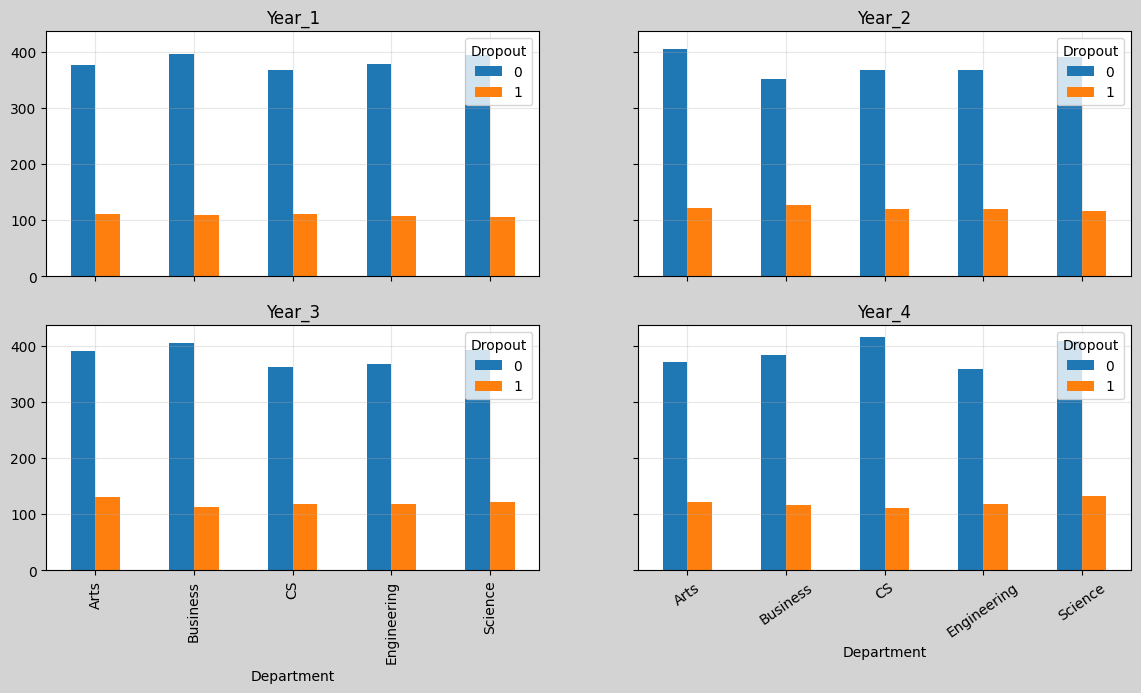

In [47]:
fig,axes=plt.subplots(2,2,figsize=(14,7),sharey=True,sharex=True,facecolor='lightgray')
Year_I.plot(kind='bar',ax=axes[0,0])
axes[0,0].grid(True,alpha=0.3)
axes[0,0].set_title('Year_1')
    
Year_II.plot(kind='bar',ax=axes[0,1])
axes[0,1].grid(True,alpha=0.3)
axes[0,1].set_title('Year_2')

    
Year_III.plot(kind='bar',ax=axes[1,0])
axes[1,0].grid(True,alpha=0.3)
axes[1,0].set_title('Year_3')

Year_IV.plot(kind='bar',ax=axes[1,1])
axes[1,1].grid(True,alpha=0.3)
axes[1,1].set_title('Year_4')

plt.tick_params(rotation=35)

                    The Percentage of Students in each Department 
We have more science students with 20.6% ,followed by Arts students with 20.3%,Bussiness with 20%, CS with 19.7% and Engineering with the least,19.4%.
However, Arts students has the highest dropout by department with 485 students,followed by science with 475 dropouts.And CS has the lowest. Although the gap between them all is not significant.

In [48]:
depts=df.groupby('Department')['Department'].value_counts()
depts

Department
Arts           2026
Business       2002
CS             1974
Engineering    1937
Science        2061
Name: count, dtype: int64

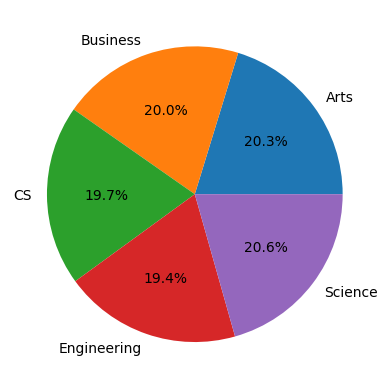

In [49]:
plt.pie(depts.values,labels=depts.index,autopct='%1.1f%%')
plt.show()

In [50]:
df.groupby('Department')['Dropout'].value_counts()

Department   Dropout
Arts         0          1541
             1           485
Business     0          1535
             1           467
CS           0          1512
             1           462
Engineering  0          1472
             1           465
Science      0          1586
             1           475
Name: count, dtype: int64

                                                                MODEL

                        Model Objective
The model is to predict whether students drop out or not. 0 represent that the student did not drop out while 1 represents that the student drops out. The objective is to capture more 0s even if some 1s are mislabeled as 0s. This is because we do not want to lose intelligent students because the dropout depends on their GPA than any other factor and smart students dropping out means a drop in the standard and quality of students in the school.

However, those who are mislabeled as 0 will encounter more exams and test which will filter them a long the line but if smart students are dropped this could cause demotivation and there may not be any measure to evaluate them or a chance to retake their exams.

Our focus is our recall score of 0 class. We need a high recall score. However, we will minimize false positive because we do not to retain a lot of students will are to dropout. Even though our focus is high recall of class 0, we make sure we balance the f1 score of both classes.

                            MODEL SELECTION
Logistic Regression will be the first model to be built and that will be our baseline model followed by DecisionTreeClassifier. These models are trained and different class imbalance techniques are used but our model is not perfect yet. More tuning is needed and other models will be used for training.

PRECAUTION 1:The raw data is used without filling the missing or null values and categorical encoding becuase of data leakage.

In [51]:
df1=pd.read_csv(r"C:\Users\USER\Desktop\MY DATASETS\student_dropout_dataset_v3.csv")
df1.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [52]:
df['Dropout'].value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

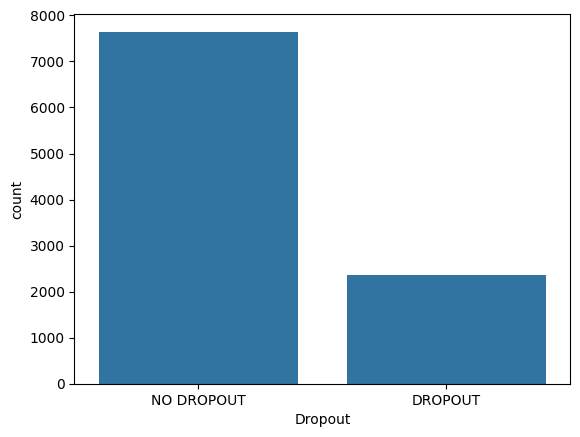

In [53]:
sns.countplot(data=df,x='Dropout')
plt.xticks(ticks=[0,1],labels=('NO DROPOUT','DROPOUT'))
plt.show()

In [54]:
Num_col=['Study_Hours_per_Day','Attendance_Rate','Assignment_Delay_Days'
         ,'Travel_Time_Minutes','Stress_Index','GPA', 'Semester_GPA', 'CGPA','Age']
Cat_col=['Gender','Internet_Access','Part_Time_Job','Scholarship','Department','Parental_Education']
meidan_col=['Family_Income']

                    selection of our features  and target variables , and spliting of our data

In [55]:
X=df1.iloc[:,1:18]
y=df1.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

                                Building of our pipeline

In [56]:
cat_pipe=Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),
                        
                         ('encode',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))])

In [57]:
num_pipe=Pipeline(steps=[('imputer',SimpleImputer(strategy='mean')),
                          ('scale',StandardScaler())])

In [58]:
median_pipe=Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),
                          ('scale',StandardScaler())])

In [59]:
preprocessing=ColumnTransformer(transformers=[('cat_seg',cat_pipe,Cat_col),
                                             ('numb_seg',num_pipe,Num_col),
                                             ('median_seg',median_pipe,meidan_col)])

In [162]:
pipe=Pipeline([('preprocessor',preprocessing),
                  ('model',LogisticRegression(class_weight={0:2,1:1},max_iter=3000))])

                TRAINING AND PREDICTION WITHOUT HANDLING THE CLASS IMBALANCE

In [163]:
pipe.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for format

In [164]:
y_train_pred=pipe.predict(X_train)

In [165]:
train_result=pd.DataFrame({'Actual': y_train,'Predicted': y_train_pred})
display(train_result.head())

,Actual,Predicted
4565,1,1
3663,0,0
8964,0,0
5778,0,0
9938,1,1


In [166]:
train_cm=confusion_matrix(y_train,y_train_pred)
train_cm

array([[5985,  132],
       [1502,  381]])

Text(50.722222222222214, 0.5, 'Actual')

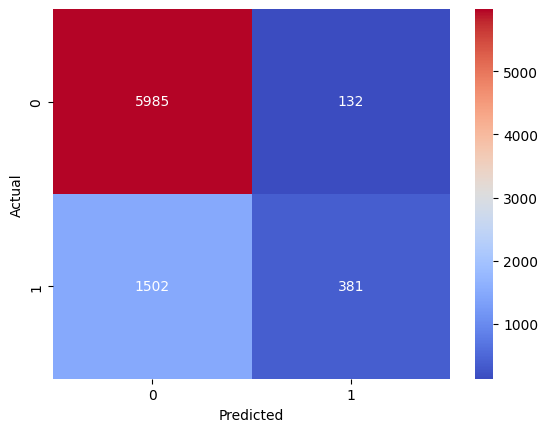

In [167]:
sns.heatmap(train_cm,annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [168]:
train_cr=classification_report(y_train,y_train_pred)
print(train_cr)

              precision    recall  f1-score   support

           0       0.80      0.98      0.88      6117
           1       0.74      0.20      0.32      1883

    accuracy                           0.80      8000
   macro avg       0.77      0.59      0.60      8000
weighted avg       0.79      0.80      0.75      8000



In [67]:
y_test_pred=pipe.predict(X_test)

In [68]:
test_result=pd.DataFrame({'Actual': y_test,'Predicted': y_test_pred})
display(test_result.head())

,Actual,Predicted
7574,0,0
3523,0,0
7890,0,0
6115,0,0
8319,1,0


In [69]:
test_cm=confusion_matrix(y_test,y_test_pred)
test_cm

array([[1438,   91],
       [ 281,  190]])

Text(50.722222222222214, 0.5, 'Actual')

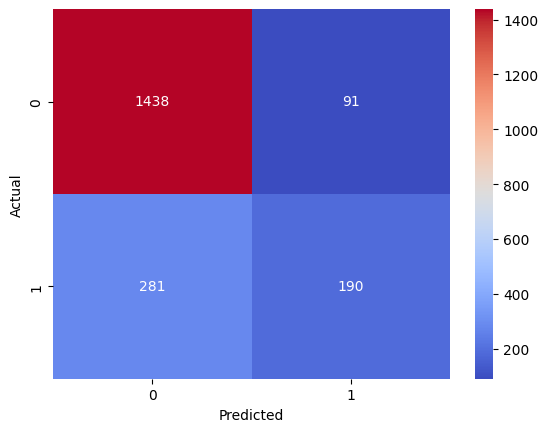

In [70]:
sns.heatmap(test_cm,annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [71]:
test_cr=classification_report(y_test,y_test_pred)
print(test_cr)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.51       471

    accuracy                           0.81      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.81      0.80      2000



                            HANDLING THE CLASS IMBALANCE USING OVERSAMPLING, UNDERSAMPLING METHODS, AND COST SENSITIVE LEARNING

    COST SENSITIVE LEARNING

In [72]:
pipe_cost=Pipeline([('preprocessor',preprocessing),
                  ('model',LogisticRegression(max_iter=3000,class_weight='balanced',random_state=42))])

In [73]:
pipe_cost.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for format

In [74]:
pred=pipe_cost.predict(X_test)

In [75]:
confusion_matrix(y_test,pred)

array([[1132,  397],
       [ 112,  359]])

Text(50.722222222222214, 0.5, 'Actual')

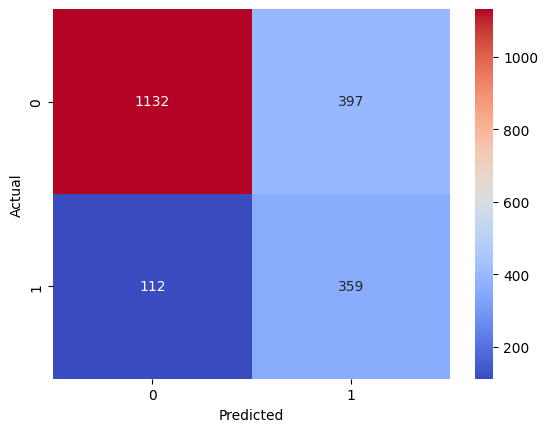

In [76]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

                                                  customised class weight

In [77]:
class_weights={0:1,1:4}

In [78]:
pipe_cust=Pipeline([('preprocessor',preprocessing),
                  ('model',LogisticRegression(max_iter=3000,class_weight=class_weights,random_state=42))])

In [79]:
pipe_cust.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for format

In [80]:
pred_cust=pipe_cust.predict(X_test)

In [81]:
confusion_matrix(y_test,pred_cust)

array([[1033,  496],
       [ 100,  371]])

Text(50.722222222222214, 0.5, 'Actual')

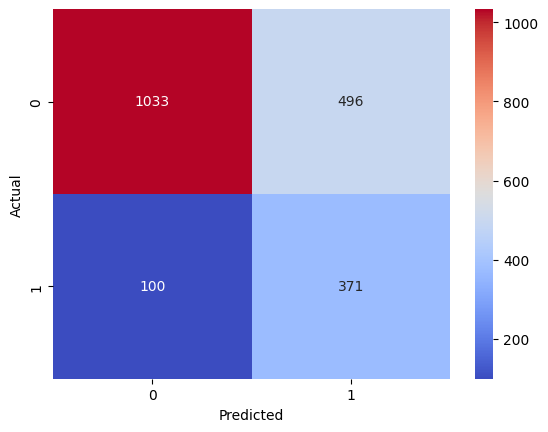

In [82]:
sns.heatmap(confusion_matrix(y_test,pred_cust),annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [83]:
print(classification_report(y_test,pred_cust))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1529
           1       0.43      0.79      0.55       471

    accuracy                           0.70      2000
   macro avg       0.67      0.73      0.67      2000
weighted avg       0.80      0.70      0.72      2000



                                                        OVERSAMPLING METHOD

In [84]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
from imblearn.over_sampling import RandomOverSampler,SMOTE,ADASYN
from imblearn.under_sampling import RandomUnderSampler,EditedNearestNeighbours

                RandomOverSampling

In [86]:
ROS=RandomOverSampler(random_state=42)
X_resampled,y_resampled=ROS.fit_resample(X_train,y_train)
class_count=y_resampled.value_counts()
class_count

Dropout
1    6117
0    6117
Name: count, dtype: int64

In [87]:
pipe.fit(X_resampled,y_resampled)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for format

In [88]:
pred_ros=pipe.predict(X_test)

Text(50.722222222222214, 0.5, 'Actual')

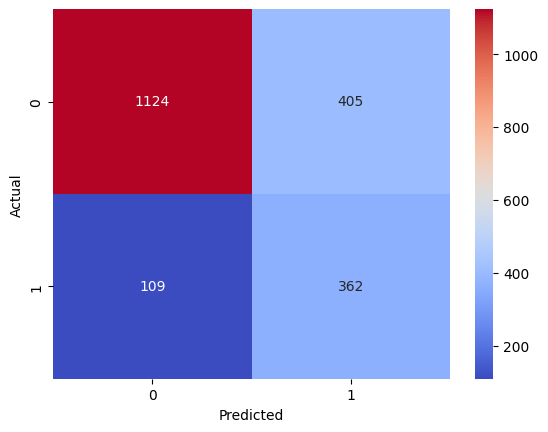

In [89]:
sns.heatmap(confusion_matrix(y_test,pred_ros),annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [90]:
print(classification_report(y_test,pred_ros))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1529
           1       0.47      0.77      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.81      0.74      0.76      2000



SMOTE-----  we have to build its pipeline bacause it can not handle categorical variables

In [91]:
from imblearn.pipeline import Pipeline

In [92]:
pipe_smote=Pipeline([('preprocessor',preprocessing),
                     ('smote',SMOTE()),
                  ('model',LogisticRegression(max_iter=3000))])

In [93]:
pipe_smote.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for f

In [94]:
pred_smote=pipe_smote.predict(X_test)

In [95]:
cm_smote=confusion_matrix(y_test,pred_smote)
cm_smote

array([[1115,  414],
       [ 118,  353]])

Text(50.722222222222214, 0.5, 'Actual')

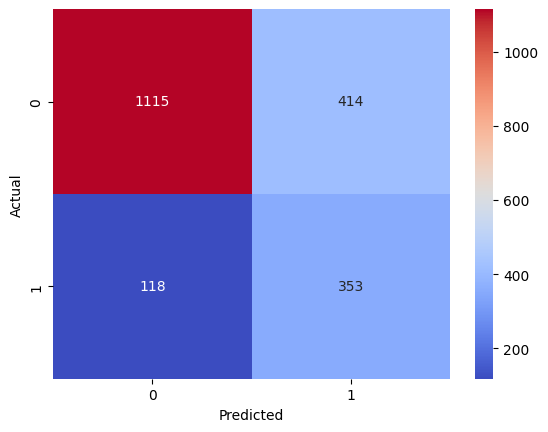

In [96]:
sns.heatmap(cm_smote,annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [97]:
print(classification_report(y_test,pred_smote))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1529
           1       0.46      0.75      0.57       471

    accuracy                           0.73      2000
   macro avg       0.68      0.74      0.69      2000
weighted avg       0.80      0.73      0.75      2000




                                                        
                                                ADASYN
Also, we have to build its pipeline

In [98]:
pipe_ada=Pipeline([('preprocessor',preprocessing),
                     ('adae',ADASYN()),
                  ('model',LogisticRegression(max_iter=3000))])

In [99]:
pipe_ada.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('adae', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for fo

In [100]:
pred_ada=pipe_ada.predict(X_test)

In [101]:
cm_ada=confusion_matrix(y_test,pred_ada)
cm_ada

array([[1074,  455],
       [ 106,  365]])

Text(50.722222222222214, 0.5, 'Actual')

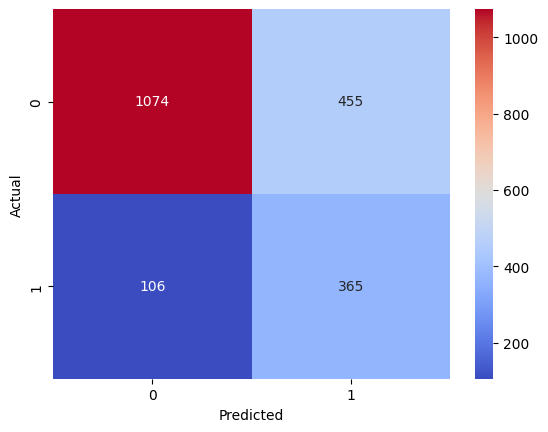

In [102]:
sns.heatmap(cm_ada,annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [103]:
print(classification_report(y_test,pred_ada))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1529
           1       0.45      0.77      0.57       471

    accuracy                           0.72      2000
   macro avg       0.68      0.74      0.68      2000
weighted avg       0.80      0.72      0.74      2000



                                                            UNDERSAMPLING

        RANDOM_UNDER_SAMPLE

In [104]:
rus=RandomUnderSampler(random_state=42)
X_resampled_under,y_resampled_under=rus.fit_resample(X_train,y_train)

In [105]:
pipe.fit(X_resampled_under,y_resampled_under)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for format

In [106]:
pred_rus=pipe.predict(X_test)

In [107]:
cm_rus=confusion_matrix(y_test,pred_rus)

Text(50.722222222222214, 0.5, 'Actual')

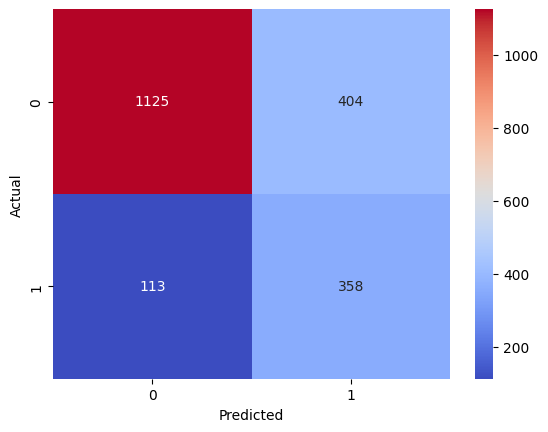

In [108]:
sns.heatmap(cm_rus,annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [109]:
cr_rus=classification_report(y_test,pred_rus)
print(cr_rus)

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1529
           1       0.47      0.76      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.81      0.74      0.76      2000



            EDITED_NEAREST_NEIGHBOURS
We need to build its pipeline because it can not handle categorical features

In [110]:
pipe_Enn=Pipeline([('preprocessor',preprocessing),
                     ('ENN',EditedNearestNeighbours()),
                  ('model',LogisticRegression(max_iter=3000))])

In [111]:
pipe_Enn.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('ENN', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for for

In [112]:
pred_Enn=pipe_Enn.predict(X_test)

In [113]:
cm_Enn=confusion_matrix(y_test,pred_Enn)

Text(50.722222222222214, 0.5, 'Actual')

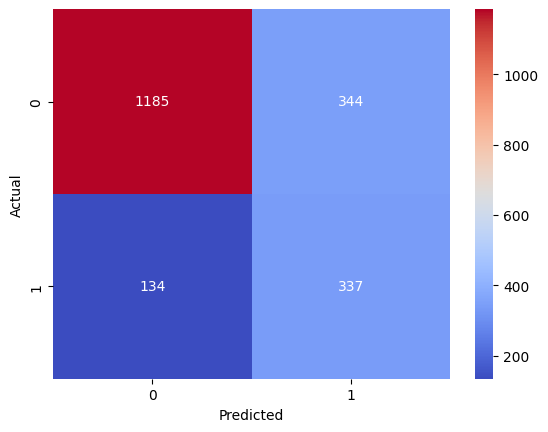

In [114]:
sns.heatmap(cm_Enn,annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [115]:
cr_Enn=classification_report(y_test,pred_Enn)
print(cr_Enn)

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1529
           1       0.49      0.72      0.59       471

    accuracy                           0.76      2000
   macro avg       0.70      0.75      0.71      2000
weighted avg       0.80      0.76      0.77      2000



                    MODEL 2 -------------------DECISIONTREECLASSIFIER

In [137]:
from sklearn.tree import DecisionTreeClassifier

In [154]:
Dtc=DecisionTreeClassifier(max_depth=5,min_samples_leaf=15,min_samples_split=15,random_state=42,class_weight={0:3.5,1:1},criterion='entropy')

In [155]:
pipe_dtc=Pipeline([('preprocessor',preprocessing),
                   ('sampler',RandomUnderSampler()),
                  ('model',Dtc)])

In [156]:
pipe_dtc.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_seg', ...), ('numb_seg', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for

In [157]:
pipe_dtc.score(X_test,y_test)

0.7425

In [158]:
dtc_pred=pipe_dtc.predict(X_test)

In [159]:
cm_dtc=confusion_matrix(y_test,dtc_pred)

Text(50.722222222222214, 0.5, 'Actual')

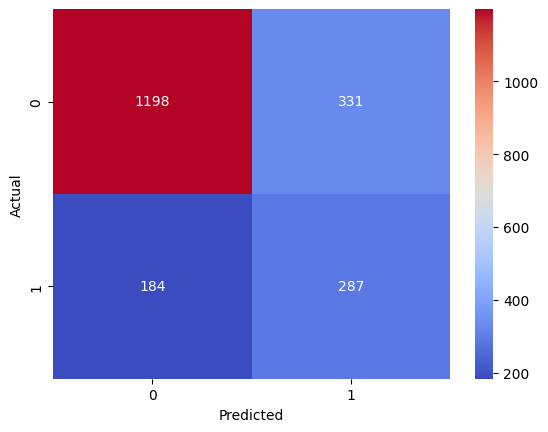

In [160]:
sns.heatmap(cm_dtc,annot=True,cmap='coolwarm',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [161]:
print(classification_report(y_test,dtc_pred))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1529
           1       0.46      0.61      0.53       471

    accuracy                           0.74      2000
   macro avg       0.67      0.70      0.68      2000
weighted avg       0.77      0.74      0.75      2000



                        HYPERPARAMETERS TUNING

In [124]:
pipe_dt=Pipeline([('preprocessor',preprocessing),
                  ('model',DecisionTreeClassifier(class_weight='balanced'))])

In [125]:
param_grid={'model__max_depth':[5,10,15,20,25,30],
           'model__min_samples_leaf':[5,10,15,20,25,30],
           'model__min_samples_split':[5,10,15,20,25,30],
           'model__criterion':['entropy','gini']}

In [126]:
gridsearch=GridSearchCV(estimator=pipe_dt,param_grid=param_grid,cv=10,n_jobs=-1,scoring='f1',verbose=1)

In [127]:
gridsearch.fit(X_train,y_train)

Fitting 10 folds for each of 432 candidates, totalling 4320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['entropy', 'gini'], 'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [5, 10, ...], 'model__min_samples_split': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [128]:
gridsearch.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 5,
 'model__min_samples_leaf': 30,
 'model__min_samples_split': 5}

In [129]:
gridsearch.best_score_

np.float64(0.5477206536930186)

In [130]:
pipe_placeholder=Pipeline([('preprocessor',preprocessing),
                  ('sampler',SMOTE()),
                  ('model',DecisionTreeClassifier(class_weight='balanced'))])

In [131]:
grid={'sampler':[SMOTE(),RandomUnderSampler(),RandomOverSampler(),ADASYN(),EditedNearestNeighbours()],
    'model__max_depth':[5,10,15,20,25,30],
           'model__min_samples_leaf':[5,10,15,20,25,30],
           'model__min_samples_split':[5,10,15,20,25,30],
           'model__criterion':['entropy','gini']}

In [132]:
search=GridSearchCV(estimator=pipe_placeholder,param_grid=grid,cv=10,n_jobs=-1,scoring='f1',verbose=1)

In [133]:
search.fit(X_train,y_train)

Fitting 10 folds for each of 2160 candidates, totalling 21600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['entropy', 'gini'], 'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [5, 10, ...], 'model__min_samples_split': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the com

In [135]:
search.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 5,
 'model__min_samples_leaf': 15,
 'model__min_samples_split': 15,
 'sampler': RandomUnderSampler()}

In [136]:
search.best_score_

np.float64(0.561315478461267)